# Compare Adjusted F1 against non-adjusted F1

Adjusted F1 removes argument mismatches attributed to split head/modifier words and preposition-object cases. This plot compares regular argument F1 against adjusted argument F1 for NL2P-1.


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from eval.read_eval import (
    DOMAIN_LABELS,
    DOMAIN_ORDER,
    METHOD_LABELS,
    MODEL_LABELS,
    MODEL_ORDER,
    read_eval_results,
)
from utils.helpers import find_project_root


ROOT = find_project_root()
RESULT_ROOT = ROOT / "results"

result_df = read_eval_results(
    RESULT_ROOT,
    domain_labels=DOMAIN_LABELS,
    method_labels=METHOD_LABELS,
    model_order=MODEL_ORDER,
)

if "Adjusted Argument F1" not in result_df.columns:
    raise ValueError(
        "evaluation_result.csv does not contain adjusted_f1. "
        "Rerun evaluation.py before drawing this figure."
    )

BASELINES = [
    ["win2k", "cEASDRL", 0.9275, 0.925],
    ["cooking", "cEASDRL", 0.852, 0.765],
    ["wikihow", "cEASDRL", 0.7843, 0.771],
    ["win2k", "cEASDRL*", 0.8393, 0.8008],
    ["cooking", "cEASDRL*", 0.7883, 0.665],
    ["wikihow", "cEASDRL*", 0.7174, 0.686],
]

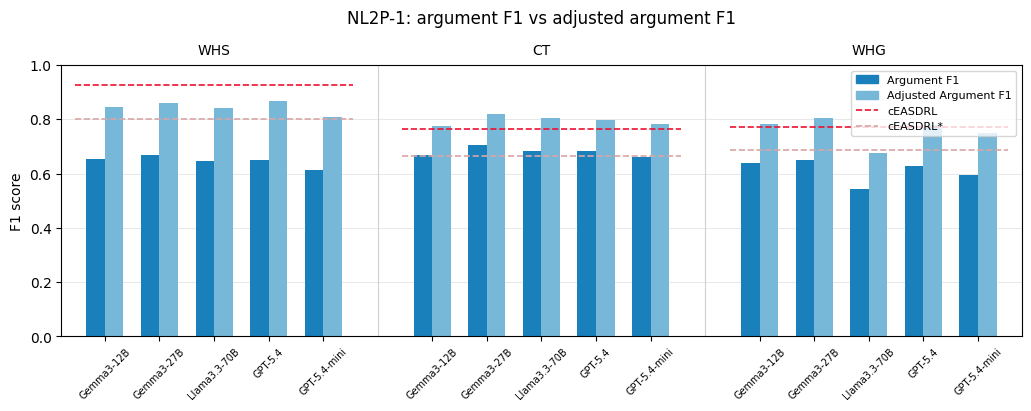

In [8]:
METHOD_KEY = "nl2p_1"

panel_df = result_df[result_df["method"].astype(str) == METHOD_KEY]
models = [model for model in MODEL_ORDER if model in set(panel_df["model"].astype(str))]
model_labels = [MODEL_LABELS.get(model, model) for model in models]

bar_width = 0.34
group_gap = 1.0
x = []
x_labels = []
domain_centers = []
domain_bounds = []
argument_f1_values = []
adjusted_f1_values = []

for domain_idx, domain in enumerate(DOMAIN_ORDER):
    start = domain_idx * (len(models) + group_gap)
    domain_x = []

    for model_idx, model in enumerate(models):
        xpos = start + model_idx
        domain_x.append(xpos)
        x.append(xpos)
        x_labels.append(model_labels[model_idx])

        row = panel_df[
            (panel_df["domain"].astype(str) == domain)
            & (panel_df["model"].astype(str) == model)
        ]
        argument_f1_values.append(np.nan if row.empty else float(row.iloc[0]["Argument F1"]))
        adjusted_f1_values.append(np.nan if row.empty else float(row.iloc[0]["Adjusted Argument F1"]))

    domain_centers.append(np.mean(domain_x))
    domain_bounds.append((min(domain_x) - 0.55, max(domain_x) + 0.55))

fig, ax = plt.subplots(figsize=(10.2, 4), constrained_layout=True)
ax.bar(
    np.array(x) - bar_width / 2,
    argument_f1_values,
    width=bar_width,
    color="#1a80bb",
    edgecolor="none",
    label="Argument F1",
)
ax.bar(
    np.array(x) + bar_width / 2,
    adjusted_f1_values,
    width=bar_width,
    color="#77b7d8",
    edgecolor="none",
    label="Adjusted Argument F1",
)

for center, domain in zip(domain_centers, DOMAIN_ORDER):
    ax.text(center, 1.03, DOMAIN_LABELS[domain], ha="center", va="bottom", fontsize=10)

for left, right in zip(domain_centers, domain_centers[1:]):
    ax.axvline((left + right) / 2, color="#cfcfcf", linewidth=0.8)

baseline_colors = {
    "cEASDRL": "#ed1131",
    "cEASDRL*": "#d8a6a6",
}
for domain, (x_min, x_max) in zip(DOMAIN_ORDER, domain_bounds):
    for baseline_domain, baseline_name, _, baseline_argument_f1 in BASELINES:
        if baseline_domain == domain:
            ax.hlines(
                baseline_argument_f1,
                x_min,
                x_max,
                color=baseline_colors[baseline_name],
                linestyle="--",
                linewidth=1.2,
            )

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, fontsize=7)
ax.set_ylabel("F1 score")
ax.set_ylim(0.0, 1.0)
ax.set_xlim(min(x) - 0.8, max(x) + 0.8)
ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#1a80bb", label="Argument F1"),
    plt.Rectangle((0, 0), 1, 1, color="#77b7d8", label="Adjusted Argument F1"),
    plt.Line2D([0], [0], color="#ed1131", linestyle="--", linewidth=1.2, label="cEASDRL"),
    plt.Line2D([0], [0], color="#d8a6a6", linestyle="--", linewidth=1.2, label="cEASDRL*"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=8)
ax.set_title(f"{METHOD_LABELS[METHOD_KEY]}: argument F1 vs adjusted argument F1", pad=30)
plt.show()
